In [ ]:
!pip install tensorflow opencv-python matplotlib seaborn kaggle

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Classroom', 'Screenshot_2025-12-18-18-45-56-56_99c04817c0de5652397fc8b56c3b3817.jpg', 'IMG_20251218_191736.jpg', 'IMG_20251226_082052.jpg', 'IMG_20260101_104114.jpg', 'Screenshot_2026-01-06-21-50-55-10_40deb401b9ffe8e1df2f1cc5ba480b12.jpg', 'Screenshot_2026-01-06-21-55-31-69_40deb401b9ffe8e1df2f1cc5ba480b12.jpg', 'IMG_20260112_174711.jpg', 'IMG_20260112_173617.jpg', 'Screenshot_2026-01-30-17-57-28-18_40deb401b9ffe8e1df2f1cc5ba480b12.jpg', 'Untitled form.gform', 'sandhiya re.pdf', 'WhatsApp Image 2026-04-22 at 12.21.53 PM.jpeg', 'ad.jpeg', 'id.pdf', 'adh.pdf', 'Colab Notebooks', 'HAM10000_metadata.csv', 'HAM10000_images_part_2', 'HAM10000_images_part_1']


In [4]:
import pandas as pd

# Path to the metadata file
metadata_path = "/content/drive/MyDrive/HAM10000_metadata.csv"

# Load the metadata
data = pd.read_csv(metadata_path)

# Display the first 5 rows
data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
# Display dataset information
print(data.info())

# Display dataset shape
print("\nDataset Shape:", data.shape)

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
None

Dataset Shape: (10015, 7)

Missing Values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


In [6]:
# Display the number of images in each disease category
print(data['dx'].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [7]:
# Disease names
disease_names = {
    'nv': 'Melanocytic Nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign Keratosis',
    'bcc': 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratoses',
    'vasc': 'Vascular Lesions',
    'df': 'Dermatofibroma'
}

print(disease_names)

{'nv': 'Melanocytic Nevi', 'mel': 'Melanoma', 'bkl': 'Benign Keratosis', 'bcc': 'Basal Cell Carcinoma', 'akiec': 'Actinic Keratoses', 'vasc': 'Vascular Lesions', 'df': 'Dermatofibroma'}


In [8]:
import os

# Image folder paths
image_dir1 = "/content/drive/MyDrive/HAM10000_images_part_1"
image_dir2 = "/content/drive/MyDrive/HAM10000_images_part_2"

print("Part 1 exists:", os.path.exists(image_dir1))
print("Part 2 exists:", os.path.exists(image_dir2))

Part 1 exists: True
Part 2 exists: True


In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Get the first image ID
image_id = data.iloc[0]['image_id']

# Check both folders
image_path = os.path.join(image_dir1, image_id + ".jpg")

if not os.path.exists(image_path):
    image_path = os.path.join(image_dir2, image_id + ".jpg")

# Display the image
img = mpimg.imread(image_path)

plt.imshow(img)
plt.title("Disease: " + data.iloc[0]['dx'])
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/HAM10000_images_part_2/ISIC_0027419.jpg'

In [10]:
import os

print(os.listdir("/content/drive/MyDrive/HAM10000_images_part_1")[:10])

['ISIC_0024330.jpg', 'ISIC_0024310.jpg', 'ISIC_0024320.jpg', 'ISIC_0024325.jpg', 'ISIC_0024314.jpg', 'ISIC_0024318.jpg', 'ISIC_0024319.jpg', 'ISIC_0024324.jpg', 'ISIC_0024313.jpg', 'ISIC_0024326.jpg']


In [11]:
print(os.listdir("/content/drive/MyDrive/HAM10000_images_part_2")[:10])

['ISIC_0029327.jpg', 'ISIC_0029315.jpg', 'ISIC_0029328.jpg', 'ISIC_0029307.jpg', 'ISIC_0029332.jpg', 'ISIC_0029319.jpg', 'ISIC_0029330.jpg', 'ISIC_0029331.jpg', 'ISIC_0029306.jpg', 'ISIC_0029340.jpg']


In [12]:
print("Images in Part 1:", len(os.listdir(image_dir1)))
print("Images in Part 2:", len(os.listdir(image_dir2)))

Images in Part 1: 215
Images in Part 2: 295


In [13]:
image_name = "ISIC_0027419.jpg"

print("Exists in Part 1:", os.path.exists(os.path.join(image_dir1, image_name)))
print("Exists in Part 2:", os.path.exists(os.path.join(image_dir2, image_name)))

Exists in Part 1: False
Exists in Part 2: False


In [14]:
import os

image_dir1 = "/content/drive/MyDrive/HAM10000_images_part_1"
image_dir2 = "/content/drive/MyDrive/HAM10000_images_part_2"

# Get image file names
images1 = os.listdir(image_dir1)
images2 = os.listdir(image_dir2)

# Combine both folders
all_images = images1 + images2

print("Total Images Available:", len(all_images))

Total Images Available: 510


In [15]:
# Create full image paths
image_paths = []

for img in images1:
    image_paths.append(os.path.join(image_dir1, img))

for img in images2:
    image_paths.append(os.path.join(image_dir2, img))

print("Total Image Paths:", len(image_paths))

Total Image Paths: 510


In [16]:
# Remove .jpg extension from image names
available_images = [os.path.splitext(img)[0] for img in all_images]

# Keep only metadata for available images
filtered_data = data[data['image_id'].isin(available_images)]

print("Filtered Dataset Shape:", filtered_data.shape)

# Show first 5 rows
filtered_data.head()

Filtered Dataset Shape: (510, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
11,HAM_0004234,ISIC_0029396,bkl,histo,85.0,female,chest
35,HAM_0000351,ISIC_0024324,bkl,histo,85.0,male,back
36,HAM_0000351,ISIC_0029559,bkl,histo,85.0,male,back
69,HAM_0005801,ISIC_0029413,bkl,histo,70.0,female,abdomen
70,HAM_0005801,ISIC_0029576,bkl,histo,70.0,female,abdomen


In [17]:
import cv2
import numpy as np

# Lists to store images and labels
X = []
y = []

# Resize all images to 128x128 pixels
IMG_SIZE = 128

for index, row in filtered_data.iterrows():
    image_name = row['image_id'] + ".jpg"

    image_path1 = os.path.join(image_dir1, image_name)
    image_path2 = os.path.join(image_dir2, image_name)

    if os.path.exists(image_path1):
        image = cv2.imread(image_path1)
    elif os.path.exists(image_path2):
        image = cv2.imread(image_path2)
    else:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    X.append(image)
    y.append(row['dx'])

print("Images Loaded:", len(X))
print("Labels Loaded:", len(y))

Images Loaded: 510
Labels Loaded: 510


In [18]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Convert images to NumPy array
X = np.array(X)

# Normalize pixel values (0-255 → 0-1)
X = X / 255.0

# Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Image Shape:", X.shape)
print("Labels Shape:", y.shape)

print("\nDisease Classes:")
print(encoder.classes_)

Image Shape: (510, 128, 128, 3)
Labels Shape: (510,)

Disease Classes:
['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [19]:
from sklearn.model_selection import train_test_split

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (408, 128, 128, 3)
Testing Images: (102, 128, 128, 3)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5784 - loss: 1.4353 - val_accuracy: 0.6176 - val_loss: 1.2506
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6397 - loss: 1.1424 - val_accuracy: 0.6275 - val_loss: 1.1215
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.6495 - loss: 1.0623 - val_accuracy: 0.6373 - val_loss: 1.0853
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6446 - loss: 1.0224 - val_accuracy: 0.6275 - val_loss: 1.1952
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6618 - loss: 1.0420 - val_accuracy: 0.6176 - val_loss: 1.1180


In [23]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 379ms/step - accuracy: 0.6176 - loss: 1.1180
Test Accuracy: 0.6176470518112183
Test Loss: 1.1179580688476562


In [24]:
model.save("skin_disease_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [25]:
from google.colab import files

files.download("skin_disease_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from google.colab import files

uploaded = files.upload()

Saving sa.jpeg to sa.jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


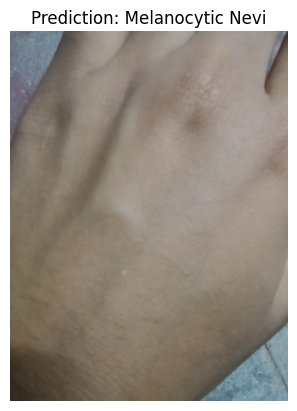

Predicted Disease Code: nv
Predicted Disease Name: Melanocytic Nevi
Confidence: 28.690475 %


In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Disease names
disease_names = {
    'akiec': 'Actinic Keratoses',
    'bcc': 'Basal Cell Carcinoma',
    'bkl': 'Benign Keratosis',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic Nevi',
    'vasc': 'Vascular Lesions'
}

# Load the uploaded image
image_path = "sa.jpeg"

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize the image
img_resized = cv2.resize(img, (128, 128))

# Normalize
img_array = img_resized / 255.0

# Reshape for prediction
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

# Get disease code
disease_code = encoder.inverse_transform([predicted_class])[0]

# Get disease name
disease_name = disease_names[disease_code]

# Display image
plt.imshow(img)
plt.axis("off")
plt.title("Prediction: " + disease_name)
plt.show()

print("Predicted Disease Code:", disease_code)
print("Predicted Disease Name:", disease_name)
print("Confidence:", np.max(prediction) * 100, "%")